# Visual Data Science Notebook on Renewable Energy Insight
This notebook helps to work through the pipeline of getting interesting information and metrics on renewable energies

## Return on investment of different countries

In [254]:

import sys
print(sys.executable)
import pandas as pd
import numpy as np
import chardet
import seaborn as snus
import matplotlib.pyplot as plt
from enum import Enum   
DATA_FOLDER = "data/"
SELECTED_COUNTRIES = ["Austria", "Belgium", "Canada", "Czechia", "Denmark", "Finland", "France", "Germany", "Greece", "Hungary",
    "Ireland", "Italy", "Japan", "Korea", "Latvia",
    "Luxembourg", "Mexico", "New Zealand", "Norway", "Poland", "Portugal",
    "Slovak Republic", "Spain", "Sweden", "Switzerland", "The Netherlands",
    "Türkiye", "United Kingdom", "United States"]#["Poland","France", "Japan","Denmark", "Switzerland", "Poland","Austria","Sweden"] #"Italy", "Spain", "United Kingdom", "Netherlands", "Sweden" #"Germany","Mexico", "Brazil","Austria", "France", "Türkiye", "Japan", "Egypt","Korea", "United States","Portugal", "Australia","Poland" 
IAE_MEMBERS = [
    "Australia", "Austria", "Belgium", "Canada", "Czechia", "Denmark",
    "Estonia", "Finland", "France", "Germany", "Greece", "Hungary",
    "Ireland", "Italy", "Japan", "Korea", "Latvia", "Lithuania",
    "Luxembourg", "Mexico", "New Zealand", "Norway", "Poland", "Portugal",
    "Slovak Republic", "Spain", "Sweden", "Switzerland", "The Netherlands",
    "Türkiye", "United Kingdom", "United States"
]
IAE_ACCESSION = [
    "Chile", "Colombia", "Costa Rica", "Israel"
]
IAE_ASSOCIATION = [
    # "Argentina", "Brazil", "China", "Egypt", "India", "Indonesia",
    # "Kenya", "Morocco", "Senegal", "Singapore", "South Africa",
    # "Thailand", "Ukraine"
]
IAE_COMBINED = IAE_MEMBERS + IAE_ACCESSION + IAE_ASSOCIATION

RDD_IMPACT_COUNTRY_SELECTION = ['Denmark','Finnland', 'Germany', 'Ireland', 'Mexico','Norway', 'Sweden', 'Poland']

class RDD_TYPE(Enum):
    TOTAL = "TOTAL"
    RENEWABLE = "RENEWABLE"
    FOSSILFUEL = "FOSSILFUEL"
   
 
COUNTRY_NAME_MAP = {
    ("United States", "United States of America"): "United States",
    ("South Korea", "Korea, Republic of", "Korea, Rep."): "Korea",
    ("Turkey", "Türkiye"): "Türkiye"
}


c:\Users\morit\miniconda3\envs\vds-env\python.exe


In [ ]:
# with open(DATA_FOLDER + 'capacity-generation-emission.csv', 'rb') as f:
#     result = chardet.detect(f.read())
#     encoding = result['encoding']
capacity_generation_emission_content = pd.read_csv(DATA_FOLDER + "capacity-generation-emission.csv", encoding='utf-8')
#print(capacity_generation_emission_content.head())

gdp_population_content = pd.read_csv(DATA_FOLDER + "gdp-population.csv")

rdd_content = pd.read_csv(DATA_FOLDER + "rdd-total-fossile-renewable.csv")

rdd_renewable_detail_content = pd.read_csv(DATA_FOLDER + "rdd_renewable_detailed.csv")








In [219]:
def uniform_country_names(df, country_column):
    for names, uniform_name in COUNTRY_NAME_MAP.items():
        df[country_column] = df[country_column].replace(names, uniform_name)
    return df

In [220]:

print("Capacity generation emission columns:")
print(capacity_generation_emission_content.columns)
capacity_generation_emission_content = capacity_generation_emission_content.drop(
    columns=[
        "EU","OECD","G7","G20","ASEAN"
        ]
)
capacity_generation_emission_content = capacity_generation_emission_content.rename(columns={"Area": "Country/Region"})
capacity_generation_emission_content = uniform_country_names(capacity_generation_emission_content, "Country/Region")
print("Cleaned capacity generation emission columns:")
print(capacity_generation_emission_content.columns)

print("\n")

print("Public rd&d investment columns:")
print(rdd_content.columns)
rdd_content = rdd_content.drop(
    columns=[
        "STRUCTURE", "STRUCTURE_ID", "STRUCTURE_NAME", "ACTION", "COUNTRY", "FREQUENCY", "Frequency",
        "RDD_SECTOR","Technology", "RDD_TYPE","Sector", "Type", "UNIT","Time Period","Observation value", "QUALIFIER", "Qualifier",
        "CONF_STATUS", "Confidential Status", "Decimals","Unit multiplier","DECIMALS"
    ]
)
rdd_content = rdd_content.rename(columns={"RDD_TECH": "Type", "TIME_PERIOD": "Year", "OBS_VALUE": "Investment Amount (Million US$)", "UNIT_MULT": "Unit Multiplier"})
rdd_content = uniform_country_names(rdd_content, "Country/Region")
print("Cleaned public rd&d investment columns:")
print(rdd_content.columns)

print("\n")

print("Gdp and population columns:")
print(gdp_population_content.columns)
#Remove unneeded columns from gdp_population_content
gdp_population_content = gdp_population_content.drop(
    columns=[   
             "Country Code", "Series Code"
    ]
)

#Remove [YRXXXX] from column names
gdp_population_content.columns = gdp_population_content.columns.str.replace(r'\[YR\d{4}\]', '', regex=True).str.strip()
gdp_population_content = pd.melt(gdp_population_content, id_vars=['Country Name', 'Series Name'],value_vars=[col for col in gdp_population_content.columns if col not in ['Country Name', 'Series Name']], var_name='Year', value_name='Value')
gdp_population_content['Value'] = pd.to_numeric(gdp_population_content['Value'], errors='coerce')
gdp_population_content = uniform_country_names(gdp_population_content, "Country Name")
print("Cleaned gdp and population columns:")
print(gdp_population_content.columns)

print("\n")


print("RDD renewable detailed columns:")
print(rdd_renewable_detail_content.columns)
rdd_renewable_detail_content = rdd_renewable_detail_content.drop(
    columns=[
        "STRUCTURE", "STRUCTURE_ID", "STRUCTURE_NAME", "ACTION", "COUNTRY", "FREQUENCY", "Frequency",
        "RDD_SECTOR","Technology", "RDD_TYPE","Sector", "Type", "UNIT","Time Period","Observation value", "QUALIFIER", "Qualifier",
        "CONF_STATUS", "Confidential Status", "Decimals","Unit multiplier","DECIMALS"
    ]
)
rdd_renewable_detail_content = rdd_renewable_detail_content.rename(columns={"RDD_TECH": "Type", "TIME_PERIOD": "Year", "OBS_VALUE": "Investment Amount (Million US$)", "UNIT_MULT": "Unit Multiplier"})
rdd_renewable_detail_content = uniform_country_names(rdd_renewable_detail_content, "Country/Region")

print("Cleaned rdd renewable detailed columns:")
print(rdd_renewable_detail_content.columns)

Capacity generation emission columns:
Index(['Area', 'ISO 3 code', 'Year', 'Area type', 'Continent', 'Ember region',
       'EU', 'OECD', 'G20', 'G7', 'ASEAN', 'Category', 'Subcategory',
       'Variable', 'Unit', 'Value', 'YoY absolute change', 'YoY % change'],
      dtype='object')
Cleaned capacity generation emission columns:
Index(['Country/Region', 'ISO 3 code', 'Year', 'Area type', 'Continent',
       'Ember region', 'Category', 'Subcategory', 'Variable', 'Unit', 'Value',
       'YoY absolute change', 'YoY % change'],
      dtype='object')


Public rd&d investment columns:
Index(['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'ACTION', 'COUNTRY',
       'Country/Region', 'FREQUENCY', 'Frequency', 'RDD_SECTOR', 'Sector',
       'RDD_TECH', 'Technology', 'RDD_TYPE', 'Type', 'UNIT', 'Unit',
       'TIME_PERIOD', 'Time Period', 'OBS_VALUE', 'Observation value',
       'QUALIFIER', 'Qualifier', 'CONF_STATUS', 'Confidential Status',
       'UNIT_MULT', 'Unit multiplier', 'DECIMALS', 'D

In [221]:
def show_scatterplot(data, x, y, hue=None, style=None, size=None,
                     title=None, xlabel=None, ylabel=None,
                     fit_line=False):

    plt.figure(figsize=(10, 6))

    snus.scatterplot(
        data=data,
        x=x,
        y=y,
        hue=hue,
        style=style,
        size=size,
        sizes=(50, 300),
        alpha=0.7
    )

    # draw straight line through points (linear regression)
    if fit_line:
        import numpy as np
        xs = data[x].astype(float)
        ys = data[y].astype(float)
        m, b = np.polyfit(xs, ys, 1)
        plt.plot(xs, m*xs + b, color='red', linewidth=2)

    plt.title(title if title else 'Scatter Plot', fontsize=14)
    plt.xlabel(xlabel if xlabel else x, fontsize=12)
    plt.ylabel(ylabel if ylabel else y, fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    

def show_bubbleplot(data, x, y, size, hue=None, title=None, xlabel=None, ylabel=None):
    """
    Creates a bubble plot where marker size encodes a numeric variable.
    """
    plt.figure(figsize=(10, 6))

    snus.scatterplot(
        data=data,
        x=x,
        y=y,
        hue=hue,
        size=size,
        sizes=(50, 800),   # bubble size range
        alpha=0.6,
        edgecolor="black",
        linewidth=0.5
    )

    plt.title(title if title else 'Bubble Plot', fontsize=14)
    plt.xlabel(xlabel if xlabel else x, fontsize=12)
    plt.ylabel(ylabel if ylabel else y, fontsize=12)

    # Move legend outside
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [227]:
def get_rdd_investment(country_list, type: RDD_TYPE):
    country_list_df = pd.DataFrame()
    for country in country_list:
        country_data = rdd_content[rdd_content['Country/Region']==country]
        rdd_type = country_data[country_data['Type']==type.value]
        country_list_df = pd.concat([country_list_df, rdd_type], ignore_index=True)
    return country_list_df

def get_rdd_investment_sum_last_n_years(country_list, duration_in_years, type: RDD_TYPE):
    df = get_rdd_investment(country_list, type).copy()
    df = df.sort_values(["Country/Region", "Year"])
    df[f"Sum_last_{duration_in_years}_years"] = (
        df.groupby("Country/Region")["Value"]
          .rolling(window=duration_in_years, min_periods=duration_in_years)
          .sum()
          .reset_index(level=0, drop=True)
    )
    df = df.dropna(subset=[f"Sum_last_{duration_in_years}_years"])
    return df



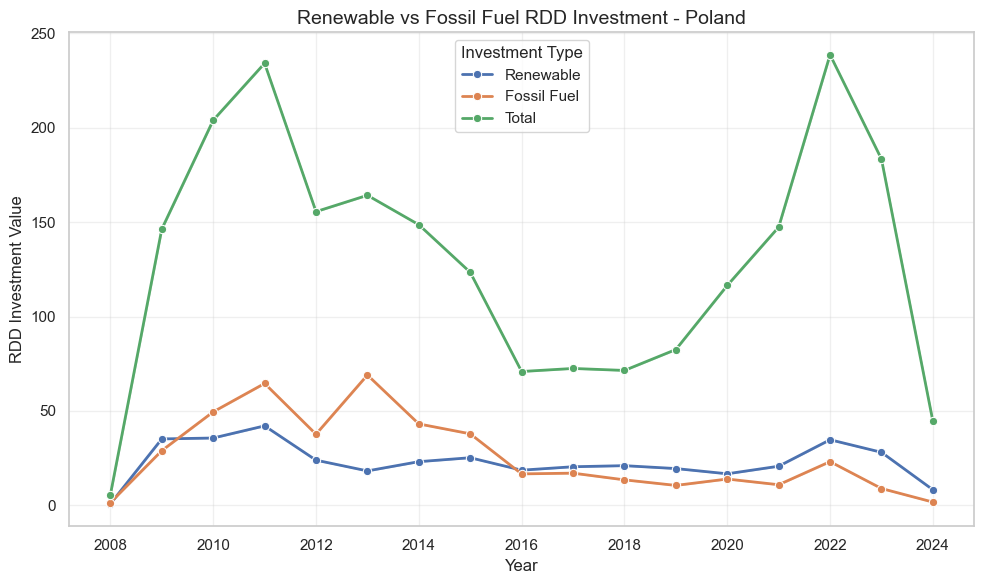

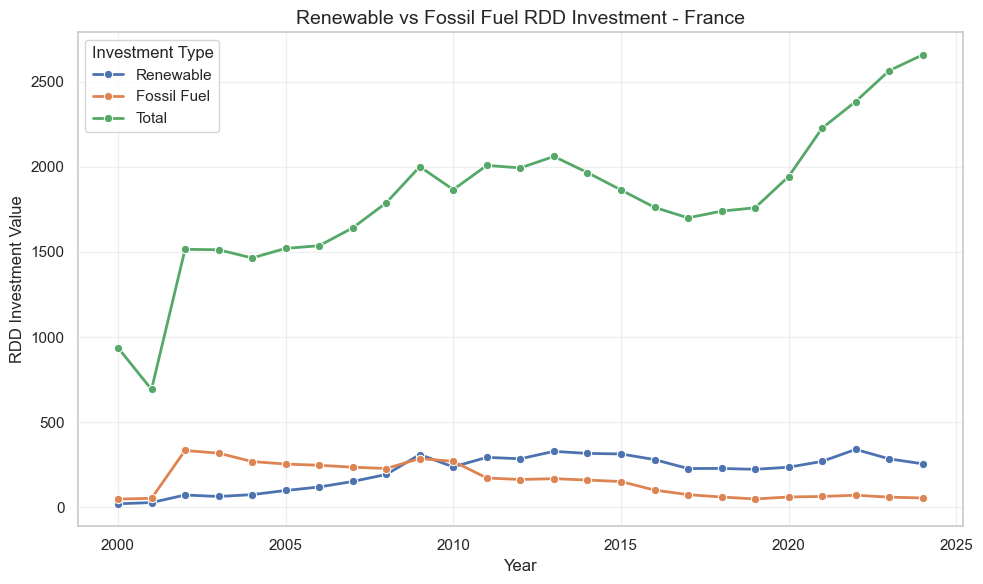

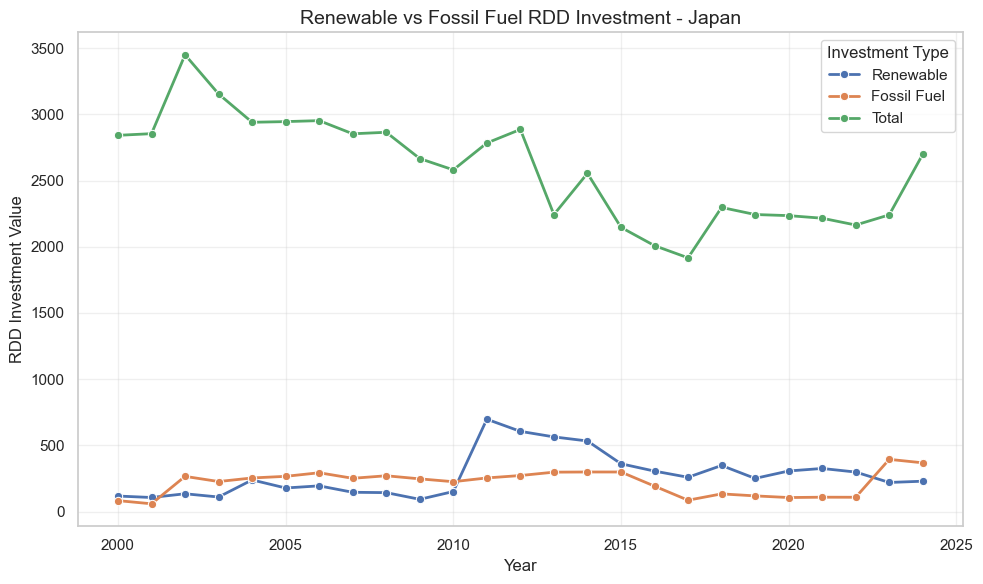

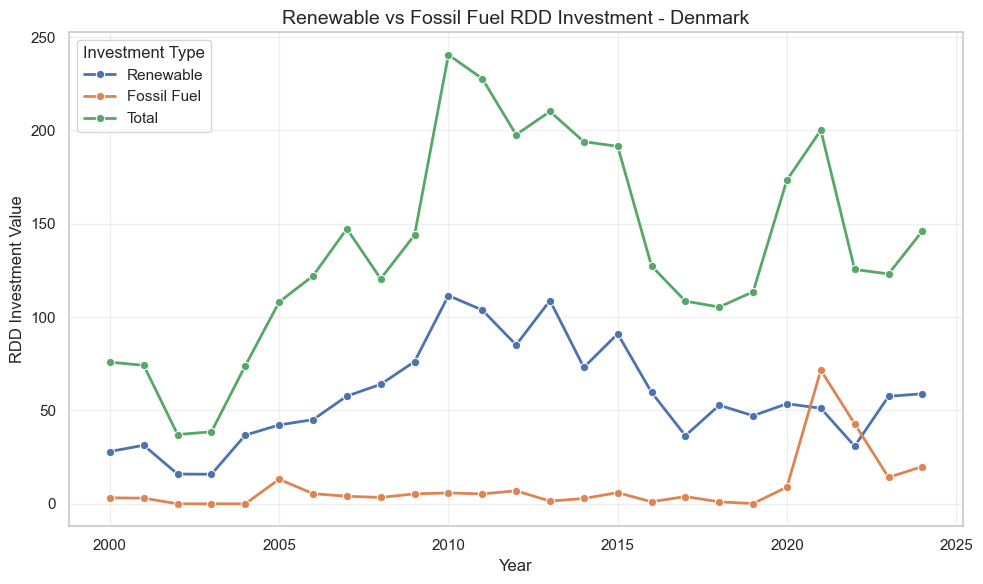

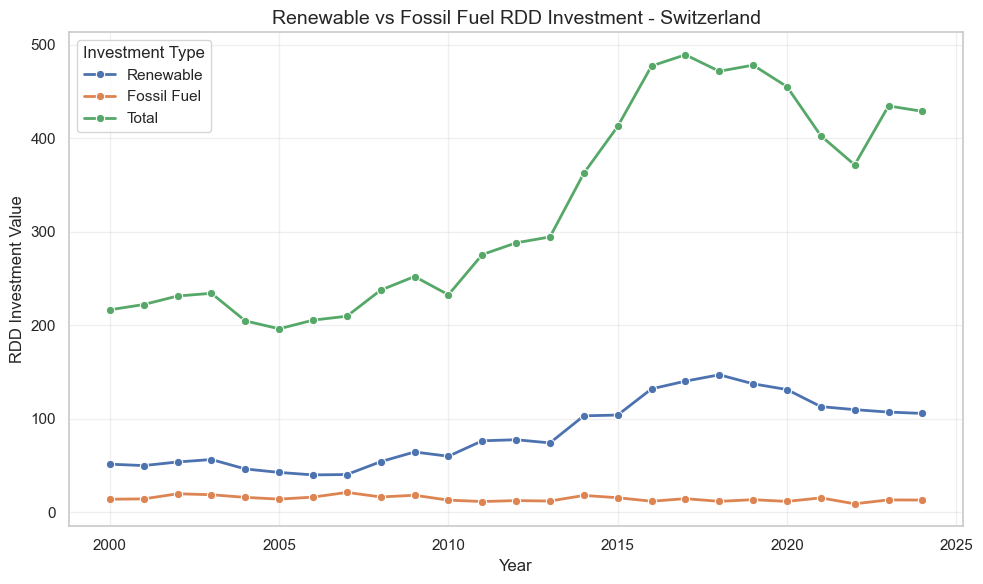

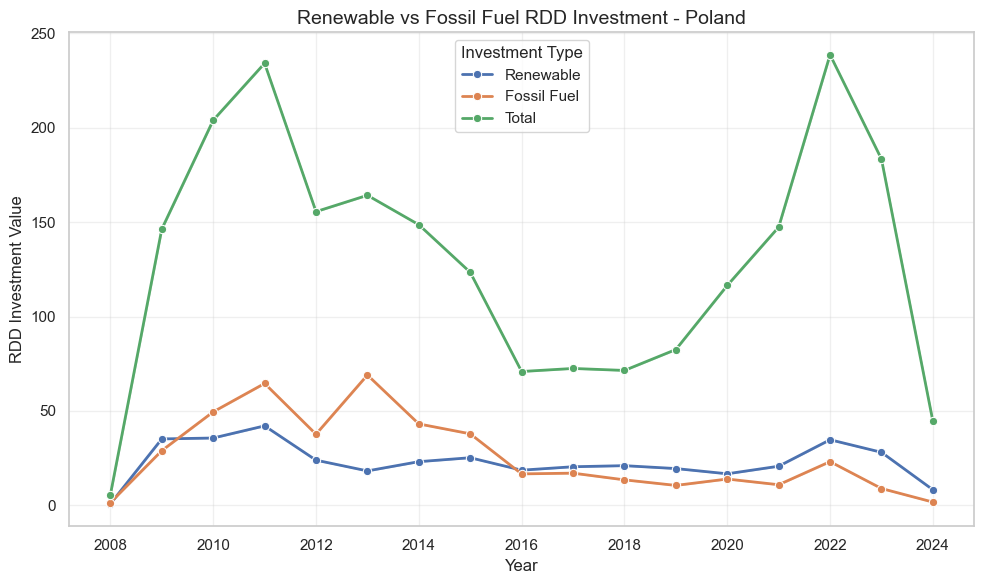

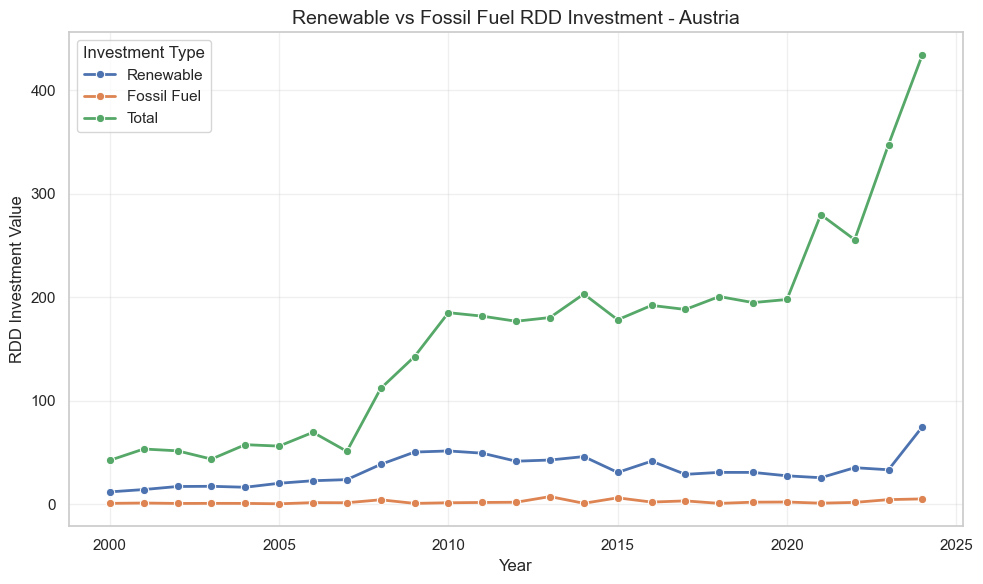

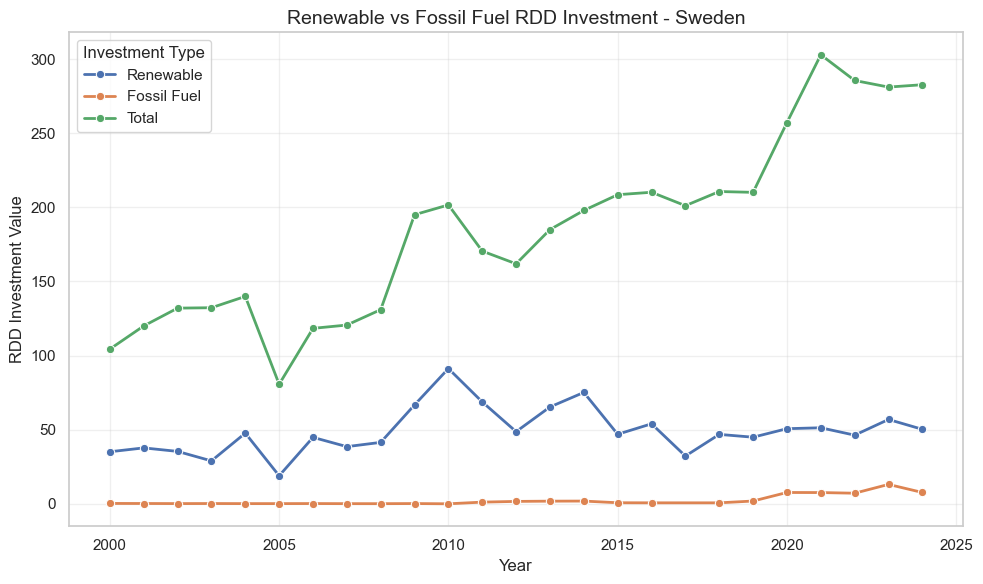

In [228]:
selected_renewable_rdd = get_rdd_investment(SELECTED_COUNTRIES, RDD_TYPE.RENEWABLE)
selected_fossilfuel_rdd = get_rdd_investment(SELECTED_COUNTRIES, RDD_TYPE.FOSSILFUEL)
selected_total_rdd = get_rdd_investment(SELECTED_COUNTRIES, RDD_TYPE.TOTAL)
selected_renewable_rdd['Investment_Type'] = 'Renewable'
selected_fossilfuel_rdd['Investment_Type'] = 'Fossil Fuel'
selected_total_rdd['Investment_Type'] = 'Total'
combined_rdd = pd.concat([selected_renewable_rdd, selected_fossilfuel_rdd, selected_total_rdd], ignore_index=True)

#Plot Renewable vs Fossilfuel RDD Investment Over Time by Country

for country in SELECTED_COUNTRIES:
    country_data = combined_rdd[combined_rdd['Country/Region'] == country]
    
    plt.figure(figsize=(10, 6))
    snus.lineplot(
        data=country_data,
        x='Year',
        y='Investment Amount (Million US$)',
        hue='Investment_Type',
        marker='o',
        linewidth=2
    )
    plt.title(f'Renewable vs Fossil Fuel RDD Investment - {country}', fontsize=14)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('RDD Investment Value', fontsize=12)
    plt.legend(title='Investment Type', loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

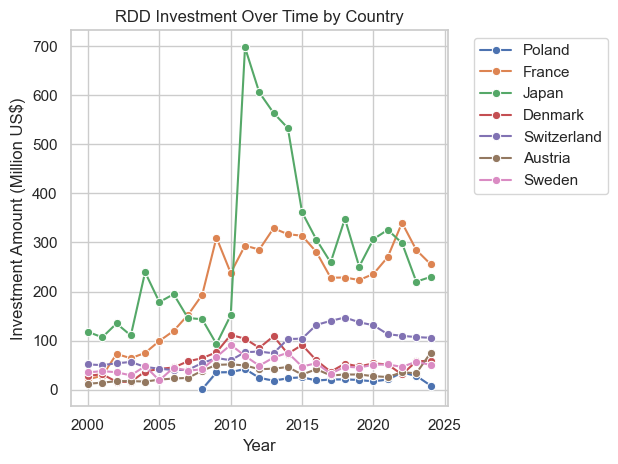

In [229]:
snus.lineplot(
    data=selected_renewable_rdd, 
    x='Year', 
    y='Investment Amount (Million US$)', 
    hue='Country/Region', 
    marker='o'
)
plt.title('RDD Investment Over Time by Country')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [257]:
def get_generation_by_country(country_list, energy_type):
    country_list_df = pd.DataFrame()
    for country in country_list:
        country_data = capacity_generation_emission_content[capacity_generation_emission_content['Country/Region']==country]
        country_data = country_data[country_data['Category'] == 'Electricity generation']
        country_data = country_data[country_data['Variable'] == energy_type]
        country_data = country_data[country_data['Unit'] == 'TWh']

        country_list_df = pd.concat([country_list_df, country_data], ignore_index=True)
    return country_list_df

def get_emissions_by_country(country_list, emission_type):
    country_list_df = pd.DataFrame()
    for country in country_list:
        country_data = capacity_generation_emission_content[capacity_generation_emission_content['Country/Region']==country]
        country_data = country_data[country_data['Category'] == 'Power sector emissions']
        country_data = country_data[country_data['Variable'] == emission_type]
        country_list_df = pd.concat([country_list_df, country_data], ignore_index=True)
    return country_list_df


def get_relative_emission_to_year_by_country(country_list, start_year, emission_type):
    emission_data = get_emissions_by_country(country_list, emission_type)
    emission_data = emission_data[emission_data['Country/Region'].isin(country_list)].copy()

    # Sort for safety
    emission_data = emission_data.sort_values(['Country/Region', 'Year'])

    # Extract baseline values for each country
    start_year_data = emission_data[emission_data['Year'] == start_year][
        ['Country/Region', 'Value']
    ].rename(columns={'Value': 'StartValue'})

    # Merge baseline into dataset
    emission_data = emission_data.merge(start_year_data, on='Country/Region', how='left')

    # Calculate percent change (positive and negative)
    emission_data['Emission change (%)'] = (
        (emission_data['Value'] / emission_data['StartValue'] - 1) * 100
    )

    # Remove rows where start value does not exist
    emission_data = emission_data.dropna(subset=['Emission change (%)'])

    return emission_data

def get_relative_renewable_generation_to_year_by_country(country_list, start_year, generation_type):
    generation_data = get_generation_by_country(country_list, generation_type)
    generation_data = generation_data[generation_data['Country/Region'].isin(country_list)].copy()

    # Sort for safety
    generation_data = generation_data.sort_values(['Country/Region', 'Year'])

    # Extract baseline values for each country
    start_year_data = generation_data[generation_data['Year'] == start_year][
        ['Country/Region', 'Value']
    ].rename(columns={'Value': 'StartValue'})

    # Merge baseline into dataset
    generation_data = generation_data.merge(start_year_data, on='Country/Region', how='left')

    # Calculate percent change (positive and negative)
    generation_data['Renewable generation change (%)'] = (
        (generation_data['Value'] / generation_data['StartValue'] - 1) * 100
    )

    # Remove rows where start value does not exist
    generation_data = generation_data.dropna(subset=['Renewable generation change (%)'])
    generation_data = generation_data.drop_duplicates(subset=['Country/Region', 'Year'])

    return generation_data



In [242]:
def get_country_gdp_sum(country_list):
    filtered = gdp_population_content[
        (gdp_population_content['Country Name'].isin(country_list)) &
        (gdp_population_content['Series Name'] == 'GDP (current US$)')
    ]
    grouped = filtered.groupby(['Country Name', 'Year'])['Value'].sum().reset_index()
    grouped = grouped.rename(columns={'Value': 'GDP'})
    return grouped

def get_country_population_sum(country_list):
    filtered = gdp_population_content[
        (gdp_population_content['Country Name'].isin(country_list)) &
        (gdp_population_content['Series Name'] == 'Population, total')
    ]
    grouped = filtered.groupby(['Country Name', 'Year'])['Value'].sum().reset_index()
    grouped = grouped.rename(columns={'Value': 'Population'})
    return grouped

def get_combined_gdp(country_list):
    gdp_data = get_country_gdp_sum(country_list)
    gdp_data = gdp_data.groupby('Year')['GDP'].sum().reset_index()
    return gdp_data

def calculate_investment_per_gdp(investment_df, gdp_df,
                                 inv_country_col='Country/Region',
                                 inv_year_col='Year',
                                 gdp_country_col='Country Name',   # optional
                                 gdp_year_col='Year',
                                 investment_col='Investment Amount (Million US$)',
                                 gdp_col='GDP'):
    inv = investment_df.copy()
    gdp = gdp_df.copy()

    # Harmonize dtypes
    inv[inv_year_col] = pd.to_numeric(inv[inv_year_col], errors='coerce').astype('Int64')
    gdp[gdp_year_col] = pd.to_numeric(gdp[gdp_year_col], errors='coerce').astype('Int64')

    inv[investment_col] = pd.to_numeric(inv[investment_col], errors='coerce')
    gdp[gdp_col]       = pd.to_numeric(gdp[gdp_col],       errors='coerce')

    # Clean strings
    if inv_country_col in inv.columns:
        inv[inv_country_col] = inv[inv_country_col].astype(str).str.strip()
    if gdp_country_col in gdp.columns:
        gdp[gdp_country_col] = gdp[gdp_country_col].astype(str).str.strip()

    # Decide merge keys
    has_gdp_country = gdp_country_col in gdp.columns
    if has_gdp_country:
        merge_left_on  = [inv_country_col, inv_year_col]
        merge_right_on = [gdp_country_col, gdp_year_col]
        validate_rule  = 'many_to_one'   # each (country, year) -> one GDP row
    else:
        merge_left_on  = [inv_year_col]
        merge_right_on = [gdp_year_col]
        validate_rule  = 'many_to_one'

    merged = pd.merge(
        inv, gdp,
        left_on=merge_left_on,
        right_on=merge_right_on,
        how='left',
        validate=validate_rule
    )

    # Avoid divide-by-zero
    denom = merged[gdp_col].replace(0, np.nan)
    merged['Investment_per_GDP'] = merged[investment_col] * np.power(10, 6) / denom

    # Pick tidy columns to return
    keep_cols = []
    if inv_country_col in merged.columns:
        keep_cols.append(inv_country_col)
    keep_cols += [inv_year_col, investment_col, gdp_col, 'Investment_per_GDP']

    return merged[keep_cols]

def calculate_relative_investment_per_gdp(country_list,comparison_country,type: RDD_TYPE):

    country_list_investment = get_rdd_investment(country_list, type)
    country_list_gdp = get_country_gdp_sum(country_list)
    country_list_investment_per_gdp = calculate_investment_per_gdp(country_list_investment, country_list_gdp)

    comparison_country_investment = get_rdd_investment([comparison_country], type)
    if(comparison_country == 'Total IEA'): 
        comparison_country_gdp = get_combined_gdp(IAE_COMBINED)
    else:
        comparison_country_gdp = get_country_gdp_sum([comparison_country])
    
    comparison_country_investment_per_gdp = calculate_investment_per_gdp(comparison_country_investment, comparison_country_gdp)

    merged = country_list_investment_per_gdp.merge(comparison_country_investment_per_gdp, on='Year', suffixes=('_country', '_comparison'))
    merged['Relative_Investment_per_GDP'] = ((merged['Investment_per_GDP_country'] / merged['Investment_per_GDP_comparison']) - 1)*100
    merged.drop(columns=['Investment Amount (Million US$)_country', 'GDP_country',
       'Investment_per_GDP_country', 'Country/Region_comparison',
       'Investment Amount (Million US$)_comparison', 'GDP_comparison',
       'Investment_per_GDP_comparison',], inplace=True)
    merged.rename(columns={'Country/Region_country': 'Country/Region'}, inplace=True)
    return merged

def get_year(df, year):
    return df[df['Year'] == year]
    

def show_relative_barplot(dataframe, year):
    df_sorted = dataframe.copy()
    
    min_val = df_sorted['Relative_Investment_per_GDP'].min()
    max_val = df_sorted['Relative_Investment_per_GDP'].max()
    
    colors = []
    for v in df_sorted['Relative_Investment_per_GDP']:
        if v < 0:
            norm = abs(v) / abs(min_val) if min_val != 0 else 0
            colors.append(plt.cm.Reds(norm * 0.4 + 0.4))
        elif v > 0:
            norm = v / max_val if max_val != 0 else 0
            colors.append(plt.cm.Greens(norm * 0.4 + 0.4))
        else:
            colors.append('lightgray')
    
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(
        df_sorted['Country/Region'],
        df_sorted['Relative_Investment_per_GDP'],
        color=colors,
        edgecolor='black',
        linewidth=0.8
    )
    
    ax.axhline(0, color='black', linewidth=1.5, zorder=0)
    ax.set_title(f'Relative RDD Investment per GDP in {year} by Country vs Total IEA', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Country/Region', fontsize=12)
    ax.set_ylabel('Relative Investment per GDP (%)', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    plt.setp(ax.xaxis.get_majorticklabels(), ha='right')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
def get_relative_investment(country_list, comparison_country, type: RDD_TYPE):
    iae_renewable_investment = get_rdd_investment([comparison_country], type)
    iae_gdp = get_combined_gdp(IAE_COMBINED)
    iae_investment_gdp_scaled = calculate_investment_per_gdp(iae_renewable_investment, iae_gdp)

    selected_countries_renewable_investment = get_rdd_investment(country_list, type)
    selected_countries_gdp = get_country_gdp_sum(country_list)
    selected_countries_investment_gdp_scaled = calculate_investment_per_gdp(selected_countries_renewable_investment, selected_countries_gdp)

    return calculate_relative_investment_per_gdp(country_list,comparison_country, type)

def get_renewable_to_fossile_rdd_ratio(country_list):
    fossile_fuel_rdd = get_rdd_investment(country_list, RDD_TYPE.FOSSILFUEL)
    renewable_rdd = get_rdd_investment(country_list, RDD_TYPE.RENEWABLE)

    relative_rdd_investments = pd.merge(
        fossile_fuel_rdd,
        renewable_rdd,
        on=['Country/Region', 'Year'],
        suffixes=('_FossilFuel', '_Renewable')
    )

    relative_rdd_investments['Renewable Percentage'] = relative_rdd_investments['Investment Amount (Million US$)_Renewable'] / (relative_rdd_investments['Investment Amount (Million US$)_Renewable'] + relative_rdd_investments['Investment Amount (Million US$)_FossilFuel']) * 100
    relative_rdd_investments['Fossile Fuel Percentage'] = relative_rdd_investments['Investment Amount (Million US$)_FossilFuel'] / (relative_rdd_investments['Investment Amount (Million US$)_Renewable'] + relative_rdd_investments['Investment Amount (Million US$)_FossilFuel']) * 100
    return relative_rdd_investments

def get_renewable_to_fossile_rdd_ratio_last_n_years(country_list, duration_in_years):
    fossile_fuel_rdd = get_rdd_investment_sum_last_n_years(country_list, duration_in_years, RDD_TYPE.FOSSILFUEL)
    renewable_rdd = get_rdd_investment_sum_last_n_years(country_list, duration_in_years, RDD_TYPE.RENEWABLE)

    relative_rdd_investments = pd.merge(
        fossile_fuel_rdd,
        renewable_rdd,
        on=['Country/Region', 'Year'],
        suffixes=('_FossilFuel', '_Renewable')
    )

    relative_rdd_investments['Renewable Percentage'] = relative_rdd_investments[f'Sum_last_{duration_in_years}_years_Renewable'] / (relative_rdd_investments[f'Sum_last_{duration_in_years}_years_Renewable'] + relative_rdd_investments[f'Sum_last_{duration_in_years}_years_FossilFuel']) * 100
    relative_rdd_investments['Fossile Fuel Percentage'] = relative_rdd_investments[f'Sum_last_{duration_in_years}_years_FossilFuel'] / (relative_rdd_investments[f'Sum_last_{duration_in_years}_years_Renewable'] + relative_rdd_investments[f'Sum_last_{duration_in_years}_years_FossilFuel']) * 100
    return relative_rdd_investments

def get_rdd_investment_cumsum_since_year(country_list, start_year, type: RDD_TYPE):
    df = get_rdd_investment(country_list, type).copy()
    # keep only years from start_year onwards
    df = df[df['Year'] >= start_year]
    if df.empty:
        return df
    df = df.sort_values(['Country/Region', 'Year'])
    df[f'Cumulative_since_{start_year}'] = (
        df.groupby('Country/Region')['Investment Amount (Million US$)']
          .cumsum()
    )
    return df

def get_renewable_to_fossile_rdd_ratio_since_year(country_list, start_year):
    fossil_rdd = get_rdd_investment_cumsum_since_year(
        country_list, start_year, RDD_TYPE.FOSSILFUEL
    )
    renewable_rdd = get_rdd_investment_cumsum_since_year(
        country_list, start_year, RDD_TYPE.RENEWABLE
    )
    rdd_combined = pd.merge(
        fossil_rdd,
        renewable_rdd,
        on=['Country/Region', 'Year'],
        suffixes=('_FossilFuel', '_Renewable')
    )
    fossil_col = f'Cumulative_since_{start_year}_FossilFuel'
    renew_col = f'Cumulative_since_{start_year}_Renewable'
    total = rdd_combined[renew_col] + rdd_combined[fossil_col]
    rdd_combined = rdd_combined[total != 0].copy()
    total = total[total != 0]

    rdd_combined['Renewable Percentage'] = (rdd_combined[renew_col] / total) * 100
    rdd_combined['Fossile Fuel Percentage'] = (rdd_combined[fossil_col] / total) * 100

    return rdd_combined


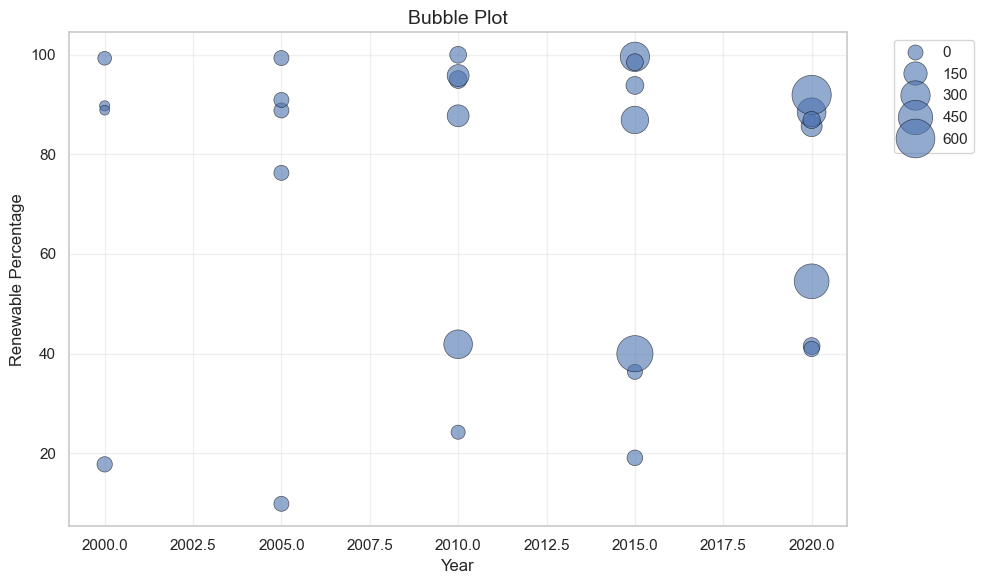

   Country/Region Type_FossilFuel                           Unit_FossilFuel  \
0         Denmark      FOSSILFUEL  USD (constant prices and exchange rates)   
5         Denmark      FOSSILFUEL  USD (constant prices and exchange rates)   
10        Denmark      FOSSILFUEL  USD (constant prices and exchange rates)   
15        Denmark      FOSSILFUEL  USD (constant prices and exchange rates)   
20        Denmark      FOSSILFUEL  USD (constant prices and exchange rates)   

    Year  Investment Amount (Million US$)_FossilFuel  \
0   2000                                       3.200   
5   2005                                      13.129   
10  2010                                       5.836   
15  2015                                       5.970   
20  2020                                       8.963   

    Unit Multiplier_FossilFuel Type_Renewable  \
0                            6      RENEWABLE   
5                            6      RENEWABLE   
10                           6      RENEW

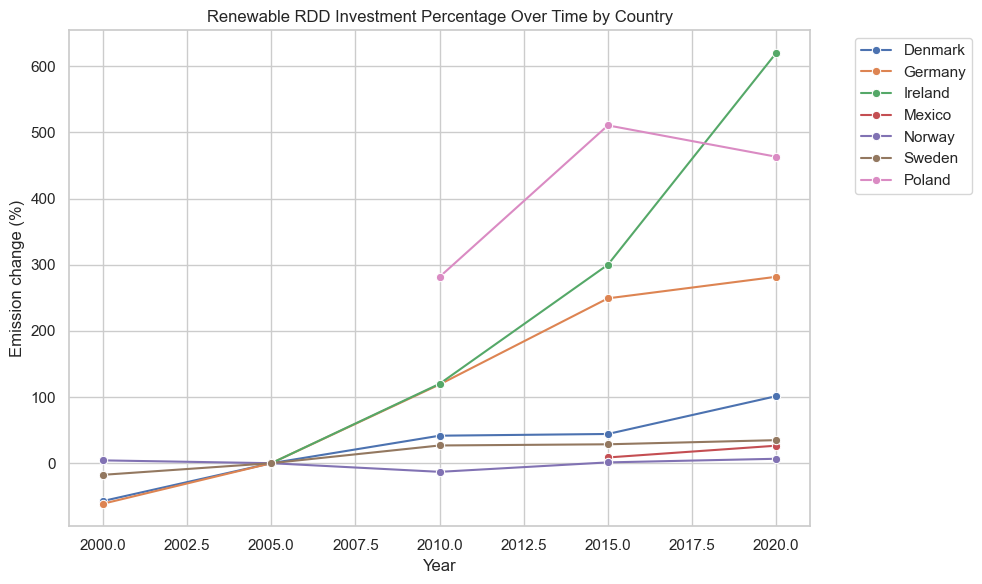

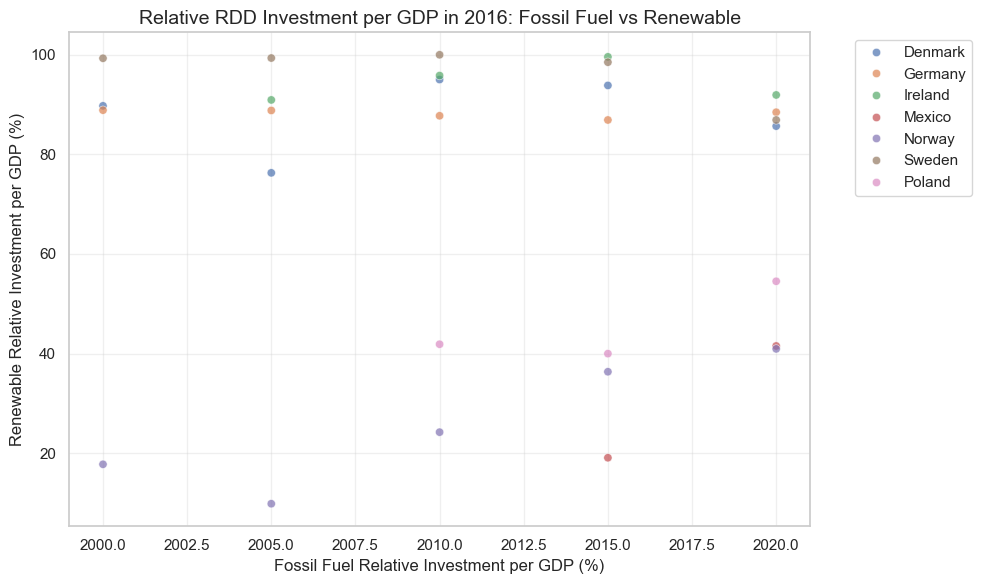

In [243]:

relative_renewable_investments = get_relative_investment(IAE_MEMBERS, 'Total IEA', RDD_TYPE.RENEWABLE)
relative_fossilfuel_investments = get_relative_investment(IAE_MEMBERS, 'Total IEA', RDD_TYPE.FOSSILFUEL)
# snus.lineplot(
#     data=relative_renewable_investments,
#     x='Year',
#     y='Relative_Investment_per_GDP',
#     hue='Country/Region',
#     marker='o'
# )
# plt.title('Relative RDD Investment per GDP Over Time by Country vs Total IEA')
# plt.axhline(0, color='gray', linestyle='--')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

# combined_investment_gdp = pd.concat([iae_investment_gdp_scaled, selected_countries_investment_gdp_scaled], ignore_index=True)
# snus.lineplot(
#     data=combined_investment_gdp, 
#     x='Year', 
#     y='Investment_per_GDP', 
#     hue='Country/Region', 
#     marker='o'
# )
# plt.title('RDD Investment per GDP Over Time by Country')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

relative_renewable_investments_2016 = get_year(relative_renewable_investments, 2016).sort_values(by='Relative_Investment_per_GDP', ascending=True)
relative_renewable_investments_2020 = get_year(relative_renewable_investments, 2020).sort_values(by='Relative_Investment_per_GDP', ascending=True)
relative_renewable_investments_2023 = get_year(relative_renewable_investments, 2023).sort_values(by='Relative_Investment_per_GDP', ascending=True)
# show_relative_barplot(relative_renewable_investments_2016, 2016)
# show_relative_barplot(relative_renewable_investments_2020, 2020)
# show_relative_barplot(relative_renewable_investments_2023, 2023)

relative_fossilfuel_investments_2016 = get_year(relative_fossilfuel_investments, 2016).sort_values(by='Relative_Investment_per_GDP', ascending=True)
relative_fossilfuel_investments_2020 = get_year(relative_fossilfuel_investments, 2020).sort_values(by='Relative_Investment_per_GDP', ascending=True)
relative_fossilfuel_investments_2023 = get_year(relative_fossilfuel_investments, 2023).sort_values(by='Relative_Investment_per_GDP', ascending=True)
# show_relative_barplot(relative_fossilfuel_investments_2016, 2016)
# show_relative_barplot(relative_fossilfuel_investments_2020, 2020)
# show_relative_barplot(relative_fossilfuel_investments_2023, 2023)



relative_emission_data = get_relative_emission_to_year_by_country(RDD_IMPACT_COUNTRY_SELECTION, 2005, 'Renewables')

relative_rdd_to_emission = pd.merge(
    relative_rdd_investments,
    relative_emission_data[['Country/Region', 'Year', 'Emission change (%)']],
    on=['Country/Region', 'Year'],
    how='inner'
)
#only very 4 years 
relative_rdd_to_emission = relative_rdd_to_emission[
    relative_rdd_to_emission['Year'] % 5 == 0
]

show_bubbleplot(
    relative_rdd_to_emission,
    x = 'Year',
    y ='Renewable Percentage',
    size='Emission change (%)'
)

print(relative_rdd_to_emission.head())
plt.figure(figsize=(10, 6))
snus.lineplot(
    data=relative_rdd_to_emission,
    x='Year',
    y='Emission change (%)',
    hue='Country/Region',
    marker='o'
)

plt.title('Renewable RDD Investment Percentage Over Time by Country')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

show_scatterplot(
    data=relative_rdd_to_emission,
    x='Year',
    y='Renewable Percentage',
    hue='Country/Region',
    title='Relative RDD Investment per GDP in 2016: Fossil Fuel vs Renewable',
    xlabel='Fossil Fuel Relative Investment per GDP (%)',
    ylabel='Renewable Relative Investment per GDP (%)'
)







## Renewable Energy RD&D Detailed View
In what kind of renewable energies do countries invest. How does this change over time ? 

In [244]:
def get_rdd_renewable_detailed(country_list):
    country_list_df = pd.DataFrame()
    for country in country_list:
        country_data = rdd_renewable_detail_content[rdd_renewable_detail_content['Country/Region']==country]
        country_list_df = pd.concat([country_list_df, country_data], ignore_index=True)
    return country_list_df

def show_renewable_detailed_investment_stacked_column_chart(country_list):
    for country in country_list:
        country_data = get_rdd_renewable_detailed([country])
        renewable_data = country_data[country_data['Type'] == 'RENEWABLE']
        country_data = country_data[country_data['Type'] != 'RENEWABLE']
        merged = pd.merge(
            country_data,
            renewable_data[['Country/Region', 'Year', 'Investment Amount (Million US$)']],
            on=['Country/Region', 'Year'],
            suffixes=('', '_Total')
        )
        
        merged['Investment Percent'] = merged['Investment Amount (Million US$)'] / merged['Investment Amount (Million US$)_Total'] * 100
        
        pivot_df = merged.pivot_table(
            index='Year',
            columns='Type',
            values='Investment Percent',
            aggfunc='sum',
            fill_value=0
        )
        
        # Sort columns by total sum (descending) so largest are at bottom of stack
        column_sums = pivot_df.sum(axis=0).sort_values(ascending=False)
        pivot_df = pivot_df[column_sums.index]
        
        pivot_df.plot(
            kind='bar',
            stacked=True,
            figsize=(12, 6),
            colormap='tab20'
        )
        plt.title(f'Renewable RDD Investment Breakdown by Technology - {country}', fontsize=14)
        plt.xlabel('Year', fontsize=12)
        plt.ylabel('Investment Percentage (%)', fontsize=12)
        plt.legend(title='Technology', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
        
        pivot_df = country_data.pivot_table(
            index='Year',
            columns='Type',
            values='Investment Amount (Million US$)',
            aggfunc='sum',
            fill_value=0
        )
        
        # Sort columns by total sum (descending) so largest are at bottom of stack
        column_sums = pivot_df.sum(axis=0).sort_values(ascending=False)
        pivot_df = pivot_df[column_sums.index]
        
        pivot_df.plot(
            kind='bar',
            stacked=True,
            figsize=(12, 6),
            colormap='tab20'
        )
        plt.title(f'Renewable RDD Investment Breakdown by Technology - {country}', fontsize=14)
        plt.xlabel('Year', fontsize=12)
        plt.ylabel('Investment (Million US$)', fontsize=12)
        plt.legend(title='Technology', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
    



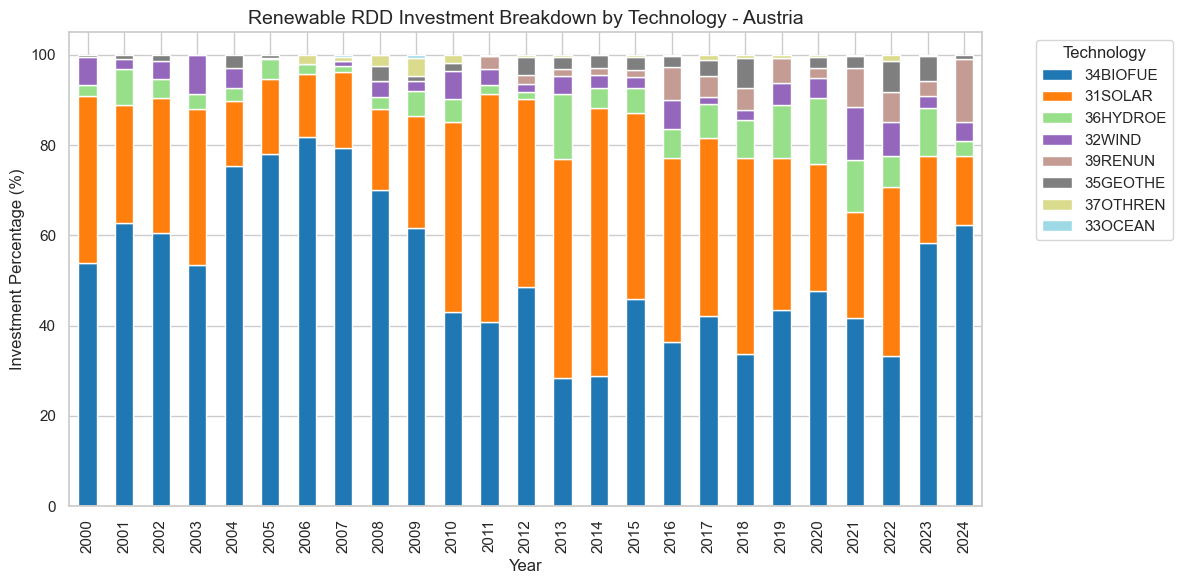

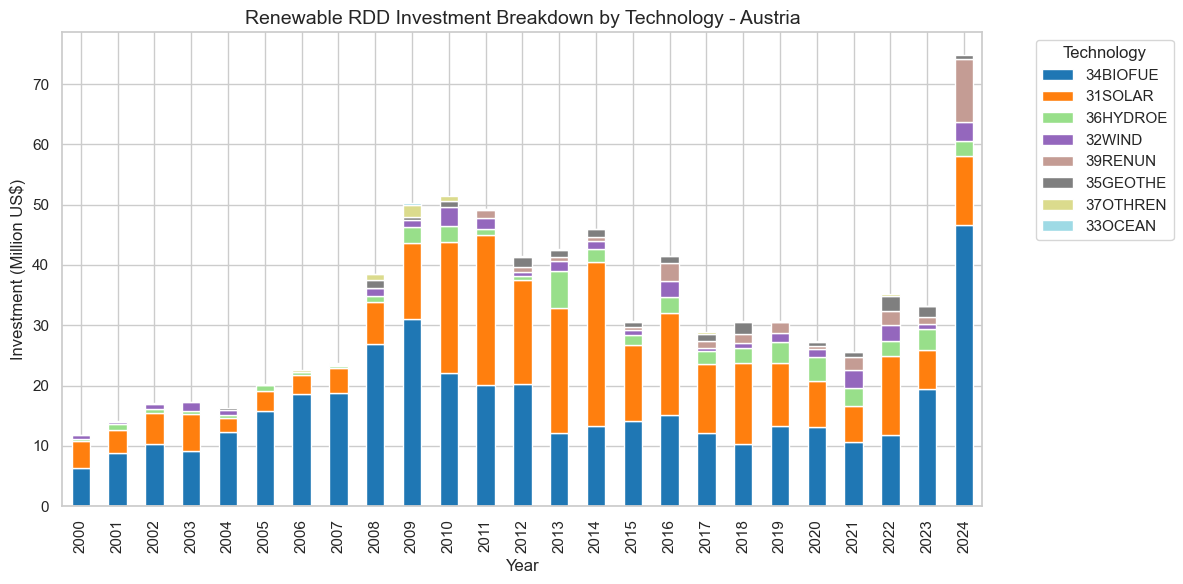

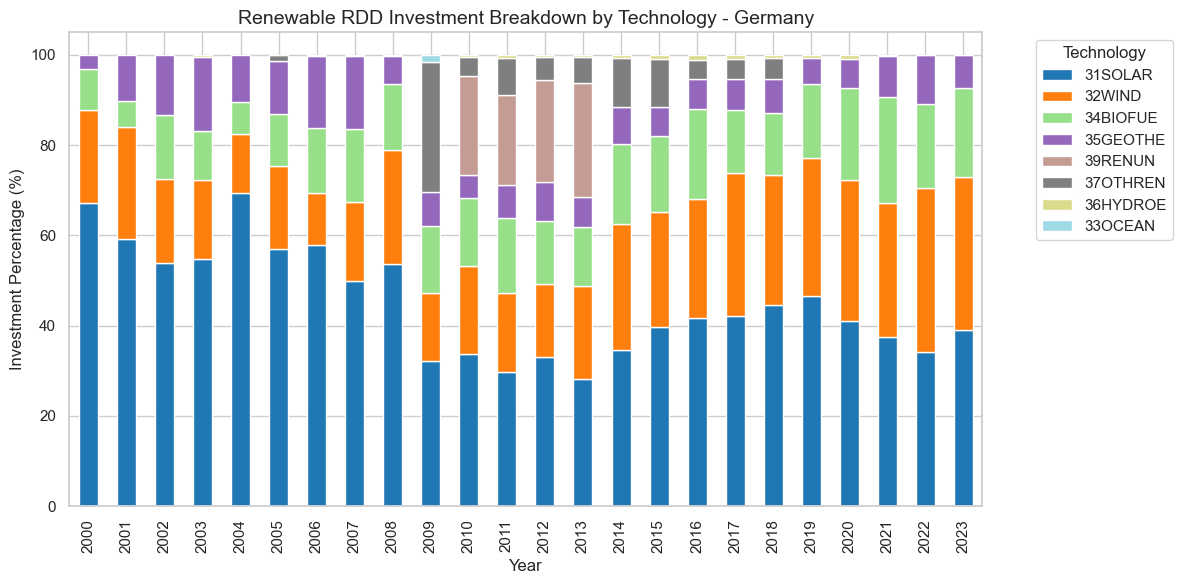

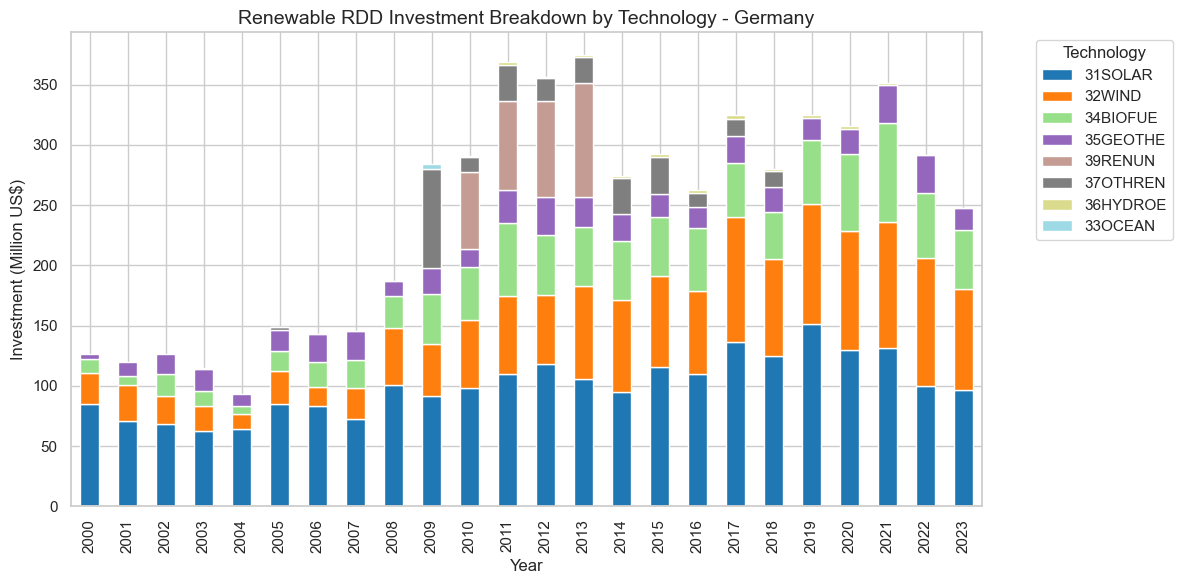

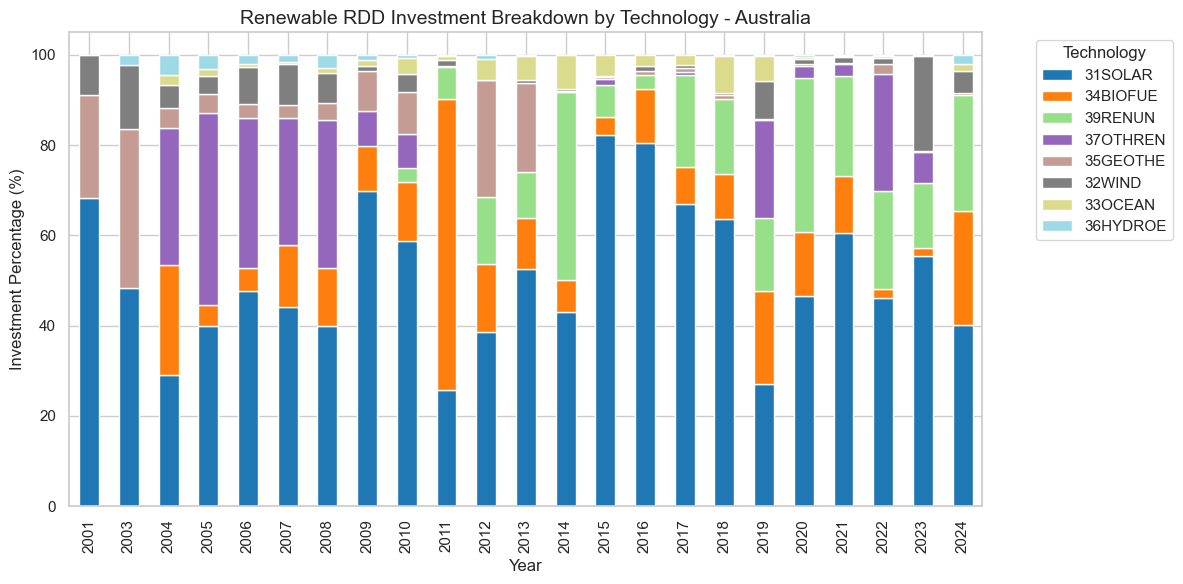

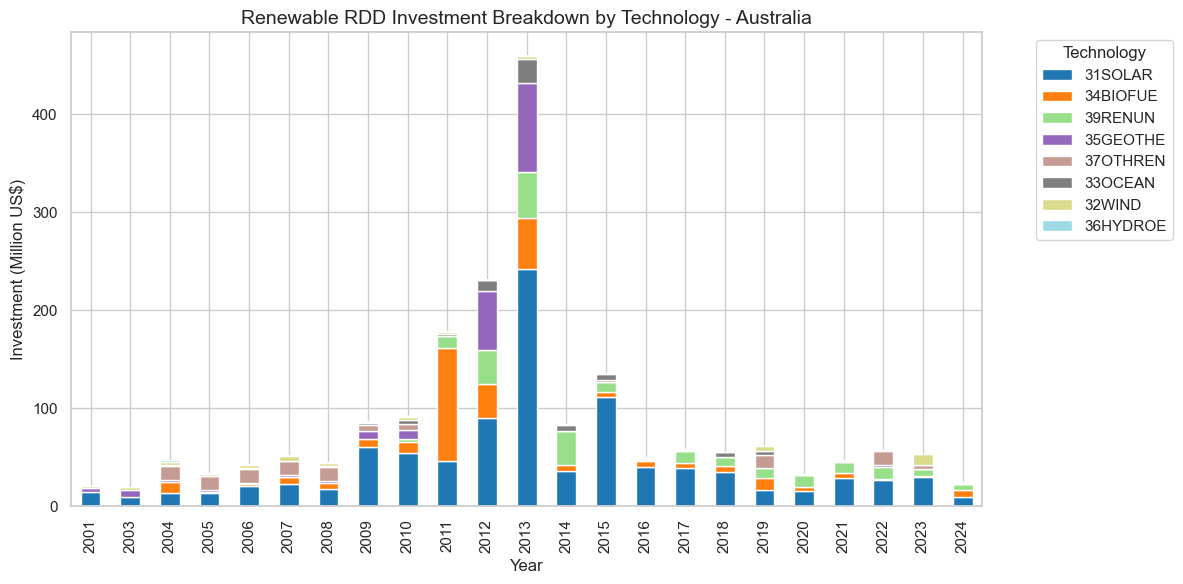

In [245]:
show_renewable_detailed_investment_stacked_column_chart(['Austria','Germany','Australia'])

## RD&D Investment relations to energy generation and CO2 emissions

Does the type of rdd investment influence type of energy generation and co2 emission ? 

I assume that the affects of rdd projects in this field take 10 years to affect generation and co2 emissions

Are countries who invest more in rdd and have a higher renewable energy percentage less subceptible to flucuating electrictiy prices.


In [246]:
def get_generation_by_country(country_list, energy_type):
    country_list_df = pd.DataFrame()
    for country in country_list:
        country_data = capacity_generation_emission_content[capacity_generation_emission_content['Country/Region']==country]
        country_data = country_data[country_data['Category'] == 'Electricity generation']
        country_data = country_data[country_data['Variable'] == energy_type]
        country_list_df = pd.concat([country_list_df, country_data], ignore_index=True)
    return country_list_df

def get_emissions_by_country(country_list, emission_type):
    country_list_df = pd.DataFrame()
    for country in country_list:
        country_data = capacity_generation_emission_content[capacity_generation_emission_content['Country/Region']==country]
        country_data = country_data[country_data['Category'] == 'Power sector emissions']
        country_data = country_data[country_data['Variable'] == emission_type]
        country_list_df = pd.concat([country_list_df, country_data], ignore_index=True)
    return country_list_df



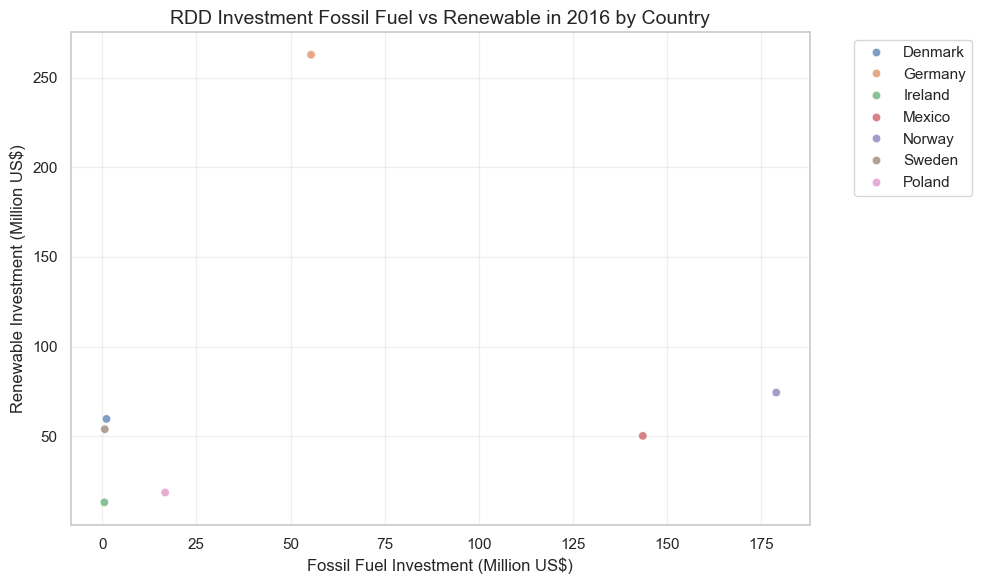

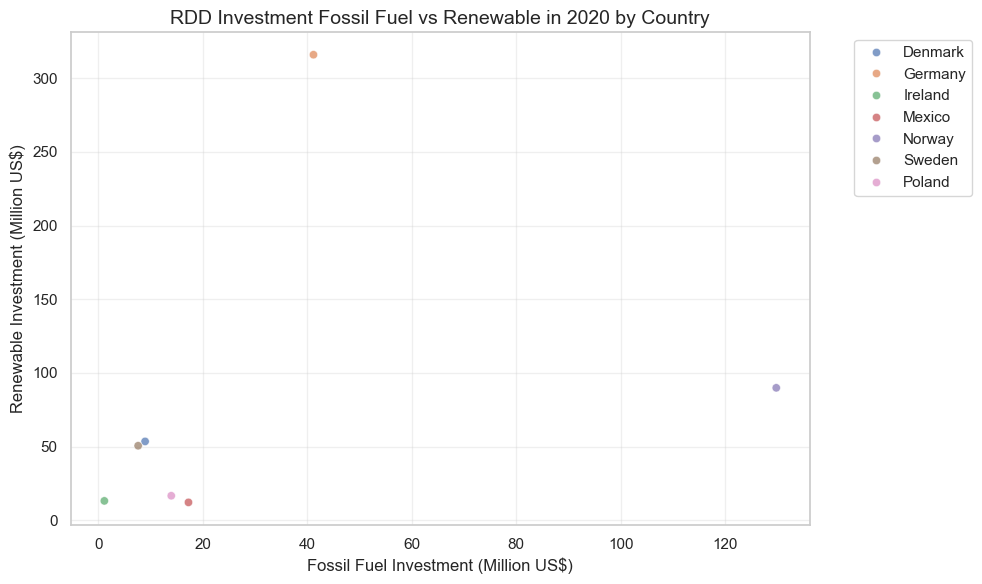

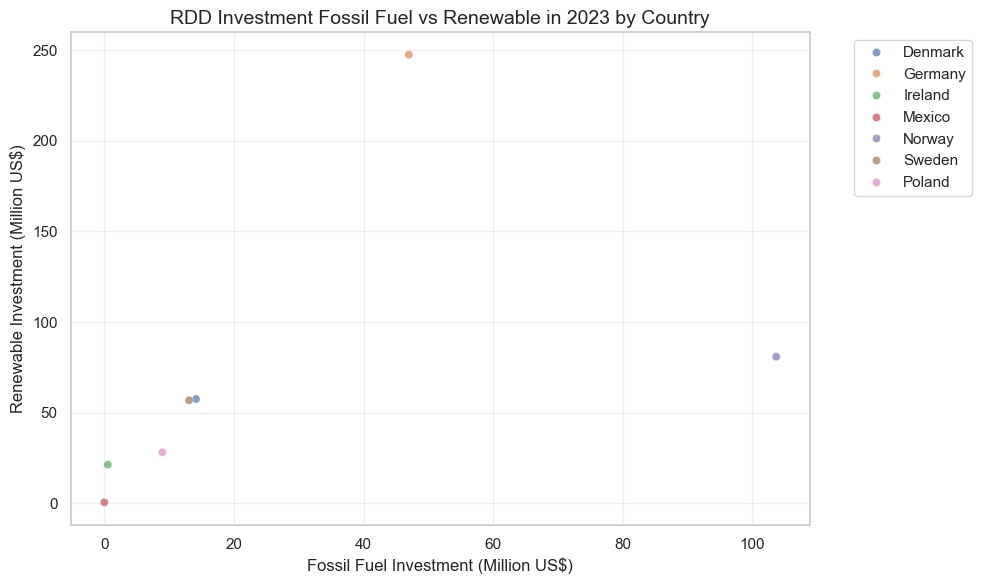

In [247]:
renewable = get_rdd_investment(RDD_IMPACT_COUNTRY_SELECTION, RDD_TYPE.RENEWABLE)
fossile = get_rdd_investment(RDD_IMPACT_COUNTRY_SELECTION, RDD_TYPE.FOSSILFUEL)

merge_rdd_investment = pd.merge(
    renewable, fossile, on=["Country/Region", "Year"], suffixes=('_renewable', '_fossile'))
merge_rdd_investment.drop(columns=['Type_renewable', 'Type_fossile', 'Unit Multiplier_renewable', 'Unit Multiplier_fossile', 'Unit_renewable', 'Unit_fossile'], inplace=True)


merge_rdd_investment_2016 = get_year(merge_rdd_investment, 2016)
merge_rdd_investment_2020 = get_year(merge_rdd_investment, 2020)
merge_rdd_investment_2023 = get_year(merge_rdd_investment, 2023)

show_scatterplot(
    data=merge_rdd_investment_2016,
    x='Investment Amount (Million US$)_fossile',
    y='Investment Amount (Million US$)_renewable',
    hue='Country/Region',
    title='RDD Investment Fossil Fuel vs Renewable in 2016 by Country',
    xlabel='Fossil Fuel Investment (Million US$)',
    ylabel='Renewable Investment (Million US$)'
)

show_scatterplot(
    data=merge_rdd_investment_2020,
    x='Investment Amount (Million US$)_fossile',
    y='Investment Amount (Million US$)_renewable',
    hue='Country/Region',
    title='RDD Investment Fossil Fuel vs Renewable in 2020 by Country',
    xlabel='Fossil Fuel Investment (Million US$)',
    ylabel='Renewable Investment (Million US$)'
)

show_scatterplot(
    data=merge_rdd_investment_2023,
    x='Investment Amount (Million US$)_fossile',
    y='Investment Amount (Million US$)_renewable',
    hue='Country/Region',
    title='RDD Investment Fossil Fuel vs Renewable in 2023 by Country',
    xlabel='Fossil Fuel Investment (Million US$)',
    ylabel='Renewable Investment (Million US$)'
)

Index(['Country/Region', 'Type_FossilFuel', 'Unit_FossilFuel', 'Year',
       'Investment Amount (Million US$)_FossilFuel',
       'Unit Multiplier_FossilFuel', 'Cumulative_since_2000_FossilFuel',
       'Type_Renewable', 'Unit_Renewable',
       'Investment Amount (Million US$)_Renewable',
       'Unit Multiplier_Renewable', 'Cumulative_since_2000_Renewable',
       'Renewable Percentage', 'Fossile Fuel Percentage',
       'Emission change (%)'],
      dtype='object')


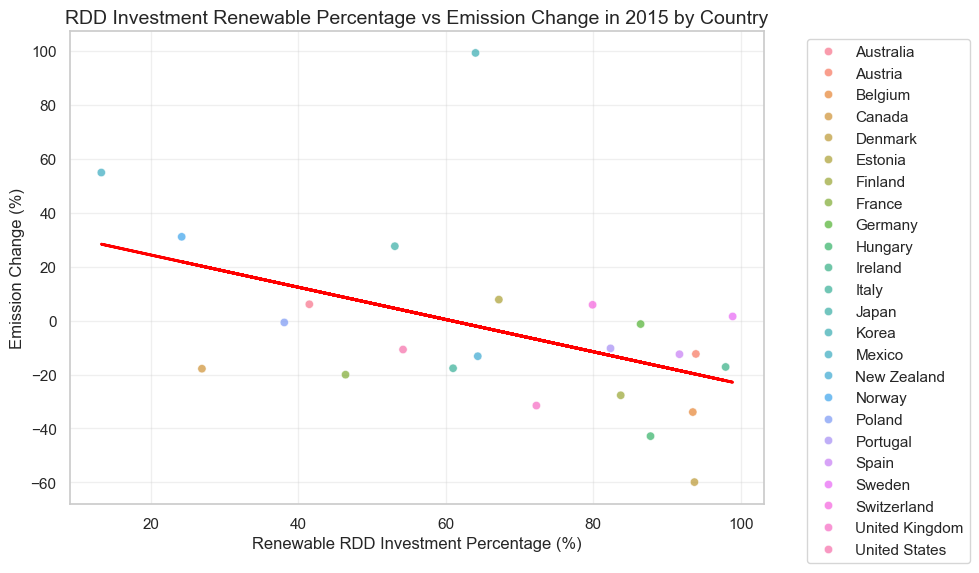

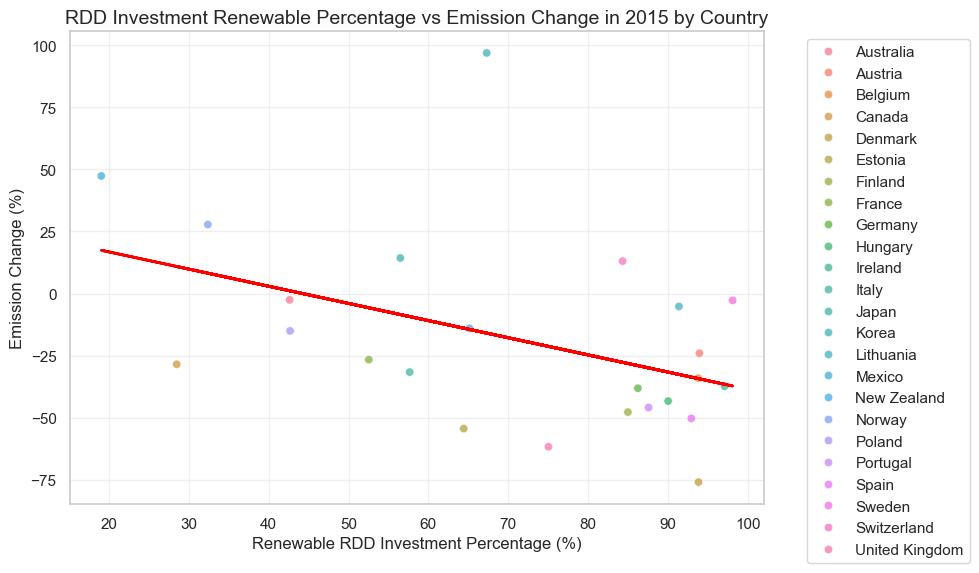

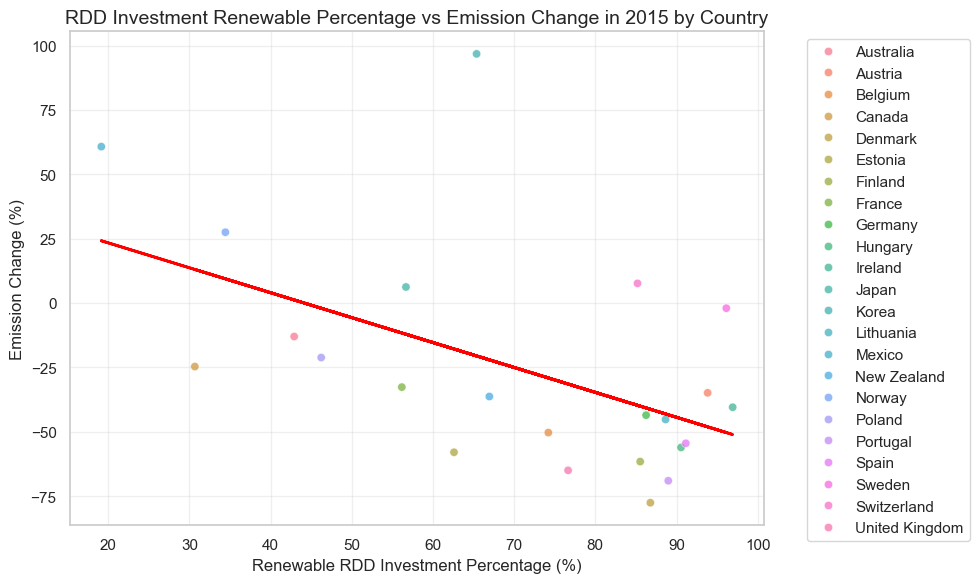

In [263]:
rdd_ratio_since_2005 = get_renewable_to_fossile_rdd_ratio_since_year(IAE_MEMBERS, 2000)
relative_emission_data = get_relative_emission_to_year_by_country(IAE_MEMBERS, 2000, 'Total emissions')
relative_rdd_to_emission = pd.merge(
    rdd_ratio_since_2005,
    relative_emission_data[['Country/Region', 'Year', 'Emission change (%)']],
    on=['Country/Region', 'Year'],
    how='inner'
)
print(relative_rdd_to_emission.columns)
#only very 4 years 
# relative_rdd_to_emission = relative_rdd_to_emission[
#     relative_rdd_to_emission['Year'] % 5 == 0
# ]


relative_rdd_to_emission_2015 = relative_rdd_to_emission[relative_rdd_to_emission['Year'] == 2015]
relative_rdd_to_emission_2020 = relative_rdd_to_emission[relative_rdd_to_emission['Year'] == 2020]
relative_rdd_to_emission_2023 = relative_rdd_to_emission[relative_rdd_to_emission['Year'] == 2023]

show_scatterplot(
    data=relative_rdd_to_emission_2015,
    x='Renewable Percentage',
    y='Emission change (%)',
    hue='Country/Region',
    title='RDD Investment Renewable Percentage vs Emission Change in 2015 by Country',
    xlabel='Renewable RDD Investment Percentage (%)',
    ylabel='Emission Change (%)',
    fit_line=True
)

show_scatterplot(
    data=relative_rdd_to_emission_2020,
    x='Renewable Percentage',
    y='Emission change (%)',
    hue='Country/Region',
    title='RDD Investment Renewable Percentage vs Emission Change in 2015 by Country',
    xlabel='Renewable RDD Investment Percentage (%)',
    ylabel='Emission Change (%)',
    fit_line=True
)

show_scatterplot(
    data=relative_rdd_to_emission_2023,
    x='Renewable Percentage',
    y='Emission change (%)',
    hue='Country/Region',
    title='RDD Investment Renewable Percentage vs Emission Change in 2015 by Country',
    xlabel='Renewable RDD Investment Percentage (%)',
    ylabel='Emission Change (%)',
    fit_line=True
)

    Country/Region ISO 3 code  Year           Area type      Continent  \
0          Austria        AUT  2000  Country or economy         Europe   
1          Austria        AUT  2001  Country or economy         Europe   
2          Austria        AUT  2002  Country or economy         Europe   
3          Austria        AUT  2003  Country or economy         Europe   
4          Austria        AUT  2004  Country or economy         Europe   
..             ...        ...   ...                 ...            ...   
670  United States        USA  2020  Country or economy  North America   
671  United States        USA  2021  Country or economy  North America   
672  United States        USA  2022  Country or economy  North America   
673  United States        USA  2023  Country or economy  North America   
674  United States        USA  2024  Country or economy  North America   

      Ember region                Category     Subcategory    Variable Unit  \
0           Europe  Electricity 

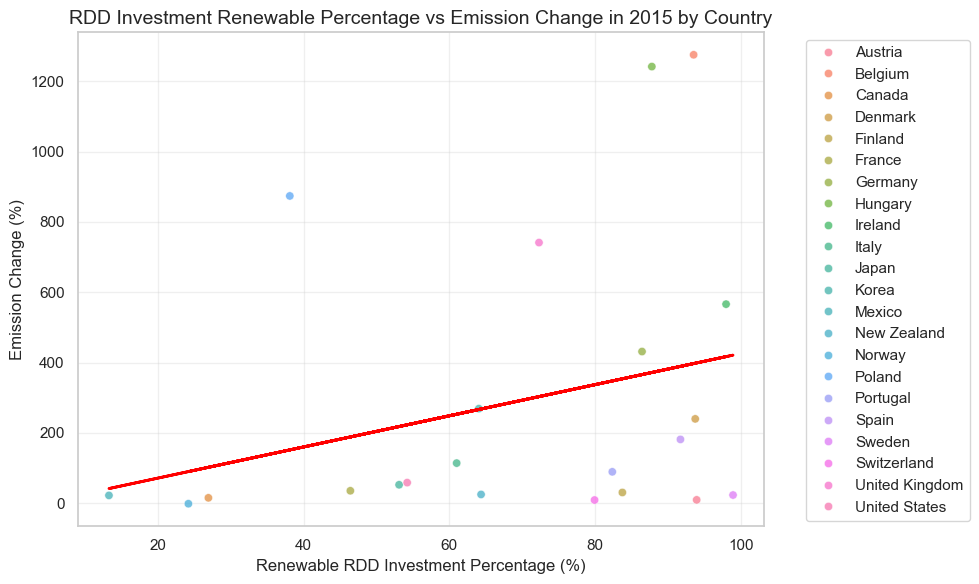

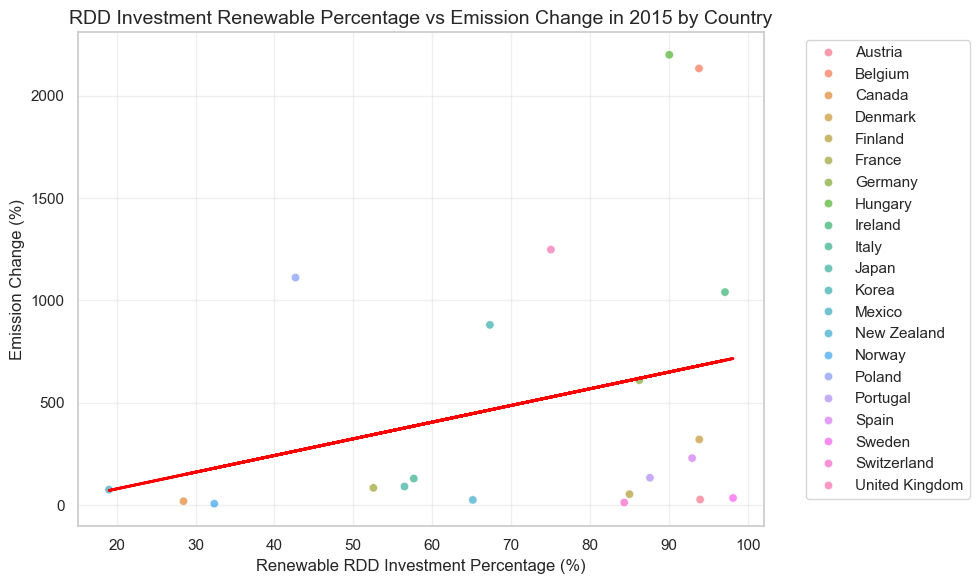

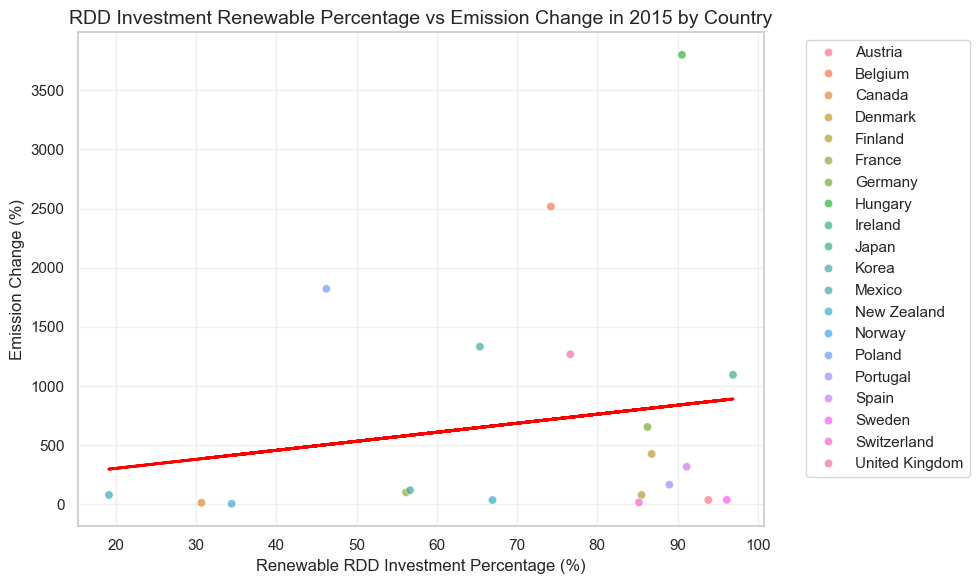

In [262]:
rdd_ratio_since_2005 = get_renewable_to_fossile_rdd_ratio_since_year(SELECTED_COUNTRIES, 2000)
relative_emission_data = get_relative_emission_to_year_by_country(SELECTED_COUNTRIES, 2000, 'Total emissions')
relative_renewable_generation = get_relative_renewable_generation_to_year_by_country(SELECTED_COUNTRIES, 2000, 'Renewables')
print(relative_renewable_generation)

relative_rdd_to_emission = pd.merge(
    rdd_ratio_since_2005,
    relative_renewable_generation[['Country/Region', 'Year', 'Renewable generation change (%)']],
    on=['Country/Region', 'Year'],
    how='inner'
)
print(relative_rdd_to_emission.columns)
#only very 4 years 
# relative_rdd_to_emission = relative_rdd_to_emission[
#     relative_rdd_to_emission['Year'] % 5 == 0
# ]


relative_rdd_to_emission_2015 = relative_rdd_to_emission[relative_rdd_to_emission['Year'] == 2015]
relative_rdd_to_emission_2020 = relative_rdd_to_emission[relative_rdd_to_emission['Year'] == 2020]
relative_rdd_to_emission_2023 = relative_rdd_to_emission[relative_rdd_to_emission['Year'] == 2023]

show_scatterplot(
    data=relative_rdd_to_emission_2015,
    x='Renewable Percentage',
    y='Renewable generation change (%)',
    hue='Country/Region',
    title='RDD Investment Renewable Percentage vs Emission Change in 2015 by Country',
    xlabel='Renewable RDD Investment Percentage (%)',
    ylabel='Emission Change (%)',
    fit_line=True
)

show_scatterplot(
    data=relative_rdd_to_emission_2020,
    x='Renewable Percentage',
    y='Renewable generation change (%)',
    hue='Country/Region',
    title='RDD Investment Renewable Percentage vs Emission Change in 2015 by Country',
    xlabel='Renewable RDD Investment Percentage (%)',
    ylabel='Emission Change (%)',
    fit_line=True
)

show_scatterplot(
    data=relative_rdd_to_emission_2023,
    x='Renewable Percentage',
    y='Renewable generation change (%)',
    hue='Country/Region',
    title='RDD Investment Renewable Percentage vs Emission Change in 2015 by Country',
    xlabel='Renewable RDD Investment Percentage (%)',
    ylabel='Emission Change (%)',
    fit_line=True
)